# LightGBM **方式2：按标的分批 + `init_model` 续训（单模型）

与 `lgb_exp.ipynb`（方式1：每批一个独立模型）对照。

本 notebook：按 `CHUNK_SIZE` 遍历标的批次，每批用 **同一 `params`** 调用 `lgb.train(..., init_model=booster)`，在上一批得到的 `Booster` 上**继续追加树**。最终仅 **一个** booster。

**注意**：续训顺序会影响结果；统计上与「全样本一次训练」不等价。


In [1]:
from pathlib import Path
import polars as pl

data_path = Path("train.parquet")
if not data_path.exists():
    raise FileNotFoundError("未找到 train.parquet，请先将文件放在当前项目目录下。")

lf = pl.scan_parquet(data_path)
col_names = lf.collect_schema().names()
n_rows = lf.select(pl.len()).collect().item()
print(f"train.parquet 行数={n_rows:,} 列数={len(col_names)}")
print("方式1：不加载全量宽表；训练按批读取列子集。")
col_names[:20]



train.parquet 行数=179,555 列数=877
方式1：不加载全量宽表；训练按批读取列子集。


["('SPY', 'close')",
 "('SPY', 'volume')",
 "('QQQ', 'close')",
 "('QQQ', 'volume')",
 "('NVDA', 'close')",
 "('NVDA', 'volume')",
 "('AAPL', 'close')",
 "('AAPL', 'volume')",
 "('MSFT', 'close')",
 "('MSFT', 'volume')",
 "('AMZN', 'close')",
 "('AMZN', 'volume')",
 "('GOOGL', 'close')",
 "('GOOGL', 'volume')",
 "('AVGO', 'close')",
 "('AVGO', 'volume')",
 "('GOOG', 'close')",
 "('GOOG', 'volume')",
 "('META', 'close')",
 "('META', 'volume')"]

In [2]:
# 解析宽表列名 -> (ticker, close/volume)，得到全市场标的列表
from lgb_data_pipeline import discover_pairs

if "col_names" not in globals():
    raise ValueError("请先运行上一格。")

pairs = discover_pairs(col_names)
valid_tickers_full = sorted([t for t, d in pairs.items() if "close" in d and "volume" in d])
print(f"总标的数量（同时有 close/volume 列）: {len(valid_tickers_full)}")



总标的数量（同时有 close/volume 列）: 438


In [3]:
CHUNK_SIZE = 30
MAX_BATCHES = None  # 冒烟测试可改为 2

n_full = len(valid_tickers_full)
n_batches = (n_full + CHUNK_SIZE - 1) // CHUNK_SIZE
print(f"标的 {n_full}，每批 {CHUNK_SIZE}，共 {n_batches} 次续训。")



标的 438，每批 30，共 15 次续训。


In [4]:
# 方式2：init_model 续训（原生 lgb.train）
from pathlib import Path
import gc
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

from lgb_data_pipeline import (
    wide_columns_for_tickers,
    wide_to_long_with_mo,
    build_feat_df,
    global_split_time_from_parquet,
)

HORIZON = 1
ROUNDS_PER_CHUNK = 400  # 每批最多追加树数；早停可能提前结束

split_time = global_split_time_from_parquet(data_path, 0.8)
print(f"全局切分: {split_time}")

batches = [
    valid_tickers_full[i : i + CHUNK_SIZE]
    for i in range(0, len(valid_tickers_full), CHUNK_SIZE)
]
if MAX_BATCHES is not None:
    batches = batches[: int(MAX_BATCHES)]

params = {
    "objective": "regression",
    "metric": "l2",
    "learning_rate": 0.03,
    "num_leaves": 63,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.1,
    "lambda_l2": 0.5,
    "verbosity": -1,
    "seed": 42,
}

base_exclude = {
    "datetime", "ticker", "close", "volume", "target_fwd_5m",
    "return_5m_lag1", "close_ma", "volume_ma", "volume_diff", "volume_diff_std",
    "close_change_rate", "close_ma_24h", "volume_ma_24h", "close_volume_corr",
    "close_volume_corr_mean", "close_volume_corr_std", "upward_mean_past_24h",
    "downward_mean_past_24h", "rs_past_24h",
}
high_freq_keep = {
    "return_5m", "volume_change_rate", "volume_change_rate_change_rate",
    "price_change_change_rate", "price_volume_direction",
    "price_breakout_confirmation", "volume_breakout_confirmation",
}
numeric_dtypes = (pl.Float32, pl.Float64, pl.Int8, pl.Int16, pl.Int32, pl.Int64)

booster = None
feature_cols_ref = None
valid_pred_parts = []  # 各批验证集预测，训练结束后拼成 way2_backtest_df

for bi, batch in enumerate(batches):
    print(f"\n>>> 续训批次 {bi + 1}/{len(batches)} 标的={len(batch)}")
    cols = wide_columns_for_tickers(pairs, batch)
    df_w = pl.read_parquet(data_path, columns=cols)
    long_df = wide_to_long_with_mo(df_w, pairs, batch)
    del df_w
    gc.collect()
    feat_df = build_feat_df(long_df)
    del long_df
    gc.collect()

    model_df = feat_df.sort(["ticker", "datetime"]).with_columns([
        (pl.col("close").shift(-HORIZON).over("ticker") / (pl.col("close") + 1e-12) - 1).alias("target_fwd_5m"),
    ])
    del feat_df
    gc.collect()

    all_numeric_cols = [c for c, dt in model_df.schema.items() if dt in numeric_dtypes]
    ewm_cols = [c for c in all_numeric_cols if c.endswith("_ewm3d")]
    hf_cols = [c for c in all_numeric_cols if c in high_freq_keep]
    feature_cols = sorted(set(ewm_cols + hf_cols) - {"target_fwd_5m"})
    if len(feature_cols) == 0:
        feature_cols = [c for c in all_numeric_cols if c not in base_exclude]

    if feature_cols_ref is None:
        feature_cols_ref = feature_cols
    elif feature_cols != feature_cols_ref:
        raise ValueError("特征列不一致")

    clean_df = model_df.with_columns([
        pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
        for c in feature_cols + ["target_fwd_5m"]
    ])
    clean_df = clean_df.filter(pl.col("target_fwd_5m").is_not_null())
    clean_df = clean_df.with_columns([
        pl.col(c).fill_null(pl.col(c).median().over("ticker")).alias(c) for c in feature_cols
    ])
    clean_df = clean_df.with_columns([
        pl.col(c).fill_null(pl.col(c).median()).fill_null(0.0).cast(pl.Float32).alias(c)
        for c in feature_cols
    ])

    train_df = clean_df.filter(pl.col("datetime") <= split_time)
    valid_df = clean_df.filter(pl.col("datetime") > split_time)
    del clean_df, model_df
    gc.collect()

    X_train = np.ascontiguousarray(train_df.select(feature_cols).to_numpy(), dtype=np.float32)
    y_train = train_df.select("target_fwd_5m").to_numpy().ravel().astype(np.float32, copy=False)
    X_valid = np.ascontiguousarray(valid_df.select(feature_cols).to_numpy(), dtype=np.float32)
    y_valid = valid_df.select("target_fwd_5m").to_numpy().ravel().astype(np.float32, copy=False)
    del train_df
    gc.collect()

    dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=True)
    dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain, free_raw_data=True)

    callbacks = [lgb.early_stopping(stopping_rounds=80, verbose=False)]
    if booster is None:
        booster = lgb.train(
            params,
            dtrain,
            num_boost_round=ROUNDS_PER_CHUNK,
            valid_sets=[dvalid],
            valid_names=["valid"],
            callbacks=callbacks,
        )
    else:
        booster = lgb.train(
            params,
            dtrain,
            num_boost_round=ROUNDS_PER_CHUNK,
            valid_sets=[dvalid],
            valid_names=["valid"],
            init_model=booster,
            callbacks=callbacks,
        )

    del dtrain, dvalid, X_train, y_train
    gc.collect()

    y_pred = booster.predict(X_valid, num_iteration=booster.best_iteration)
    rmse = mean_squared_error(y_valid, y_pred) ** 0.5
    r2 = r2_score(y_valid, y_pred)
    print(f"    本批 valid RMSE={rmse:.8f} R2={r2:.6f} best_iter_total={booster.best_iteration}")

    valid_pred_parts.append(
        valid_df.select(["datetime", "ticker", "target_fwd_5m"]).with_columns(
            pl.Series("pred_ret_5m", np.asarray(y_pred, dtype=np.float64))
        )
    )
    del X_valid, y_valid, valid_df
    gc.collect()

feature_cols = feature_cols_ref
way2_booster = booster
way2_backtest_df = pl.concat(valid_pred_parts).sort(["datetime", "ticker"])
WAY2_INIT_MODEL = True
print("\n续训完成。way2_booster / feature_cols / way2_backtest_df（全批验证合并）已就绪。")



全局切分: 2024-05-07 15:25:00-04:00

>>> 续训批次 1/15 标的=30
    本批 valid RMSE=0.00231986 R2=0.000303 best_iter_total=47

>>> 续训批次 2/15 标的=30
    本批 valid RMSE=0.00242430 R2=0.000538 best_iter_total=82

>>> 续训批次 3/15 标的=30
    本批 valid RMSE=0.00224388 R2=-0.000104 best_iter_total=94

>>> 续训批次 4/15 标的=30
    本批 valid RMSE=0.00236190 R2=-0.001268 best_iter_total=98

>>> 续训批次 5/15 标的=30
    本批 valid RMSE=0.00230732 R2=-0.001049 best_iter_total=105

>>> 续训批次 6/15 标的=30
    本批 valid RMSE=0.00253013 R2=-0.000361 best_iter_total=201

>>> 续训批次 7/15 标的=30
    本批 valid RMSE=0.00233281 R2=-0.000273 best_iter_total=202

>>> 续训批次 8/15 标的=30
    本批 valid RMSE=0.00238160 R2=-0.000513 best_iter_total=205

>>> 续训批次 9/15 标的=30
    本批 valid RMSE=0.00236439 R2=0.000759 best_iter_total=206

>>> 续训批次 10/15 标的=30
    本批 valid RMSE=0.00254316 R2=-0.000412 best_iter_total=220

>>> 续训批次 11/15 标的=30
    本批 valid RMSE=0.00222269 R2=-0.000444 best_iter_total=224

>>> 续训批次 12/15 标的=30
    本批 valid RMSE=0.00219256 R2=0.0007

In [5]:
# 可选：保存单模型
from pathlib import Path
import joblib

out = Path("artifacts")
out.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {"booster": way2_booster, "feature_cols": feature_cols, "mode": "way2_init_model"},
    out / "lgb_way2_booster.pkl",
)
print("已保存", out / "lgb_way2_booster.pkl")



已保存 artifacts\lgb_way2_booster.pkl


### Visualization

- **Left:** Top-25 feature importance by **gain** from `way2_booster`.
- **Right:** Scatter of **prediction vs. target** on the pooled validation set (random subsample).
- **Bottom:** Time series of cross-sectional **mean prediction / mean target** at each 5m bar.
- **Last:** **Histogram** of prediction errors `pred - target` (same random subsample as the scatter).

d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 65289 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 39564 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 35777 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 38598 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 65306 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-package

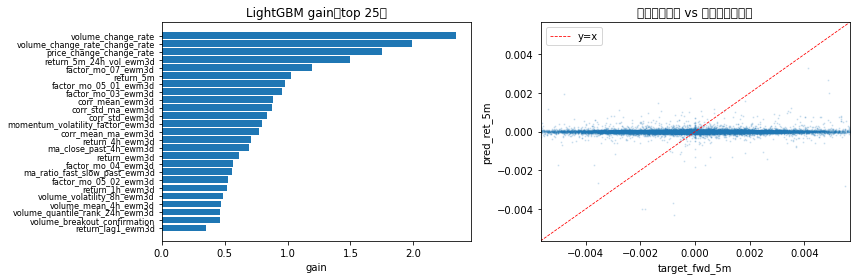

d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 39564 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 35777 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 21306 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 38388 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 65306 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 27599 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-package

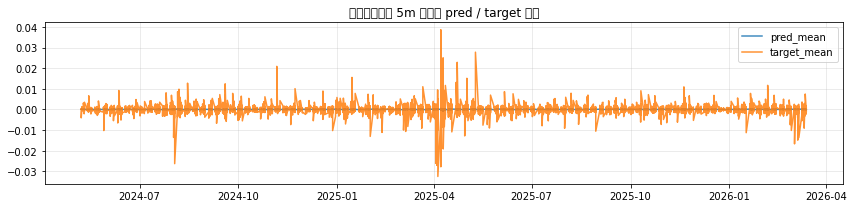

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

if "way2_booster" not in globals() or "way2_backtest_df" not in globals():
    raise ValueError("Run the training cell first so way2_booster and way2_backtest_df exist.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

imp = way2_booster.feature_importance(importance_type="gain")
order = np.argsort(imp)[::-1][:25]
names = [feature_cols[i] for i in order]
ax = axes[0]
ax.barh(range(len(names)), imp[order][::-1])
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names[::-1], fontsize=8)
ax.set_title("LightGBM gain (top 25)")
ax.set_xlabel("gain")

n = way2_backtest_df.height
sub_n = min(50_000, n)
sample = way2_backtest_df.sample(n=sub_n, shuffle=True, seed=42) if n > 0 else way2_backtest_df
y_t = sample["target_fwd_5m"].to_numpy()
y_p = sample["pred_ret_5m"].to_numpy()
ax2 = axes[1]
ax2.scatter(y_t, y_p, s=1, alpha=0.15)
lim = float(np.quantile(np.abs(np.concatenate([y_t, y_p])), 0.99)) if len(y_t) else 1e-3
lim = max(lim, 1e-6)
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.plot([-lim, lim], [-lim, lim], "r--", lw=0.8, label="y=x")
ax2.set_xlabel("target_fwd_5m")
ax2.set_ylabel("pred_ret_5m")
ax2.set_title("Validation: prediction vs. target (subsample)")
ax2.legend()

plt.tight_layout()
plt.show()

ts = (
    way2_backtest_df.group_by("datetime")
    .agg([
        pl.col("pred_ret_5m").mean().alias("pred_mean"),
        pl.col("target_fwd_5m").mean().alias("target_mean"),
    ])
    .sort("datetime")
)
plot_ts = ts.to_pandas()
plt.figure(figsize=(12, 3))
plt.plot(plot_ts["datetime"], plot_ts["pred_mean"], label="pred_mean", alpha=0.85)
plt.plot(plot_ts["datetime"], plot_ts["target_mean"], label="target_mean", alpha=0.85)
plt.title("Validation: cross-sectional mean pred / target by bar")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Prediction error distribution (same subsample as scatter) ---
err = (sample["pred_ret_5m"] - sample["target_fwd_5m"]).to_numpy()
plt.figure(figsize=(10, 4))
plt.hist(err, bins=100, density=True, alpha=0.75, color="steelblue", edgecolor="white", linewidth=0.3)
plt.axvline(0.0, color="crimson", linestyle="--", linewidth=1, label="Zero error")
plt.xlabel("Prediction error (pred - target)")
plt.ylabel("Density")
plt.title("Distribution of prediction errors (validation subsample)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 回测（验证区间）

与 `lgb_exp` 中思路一致：每个时点按 `pred_ret_5m` 截面排名，做多 **Top-K** 标的，等权持有 5 分钟，累计净值。

回测统计（方式2 · 验证区间 · 全批标的合并）
mean_ret_5m: 0.00020385747174172787
std_ret_5m: 0.004940966215145206
sum_ret_5m: 7.320317952773706
final_nav: 987.2617059462908
avg_holdings: 1.0


d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 39564 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 35777 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 21306 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 38388 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 20928 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 20540 missing from current font.
  font.set_text(s, 0.0, flags=flags)
d:\anaconda\lib\site-package

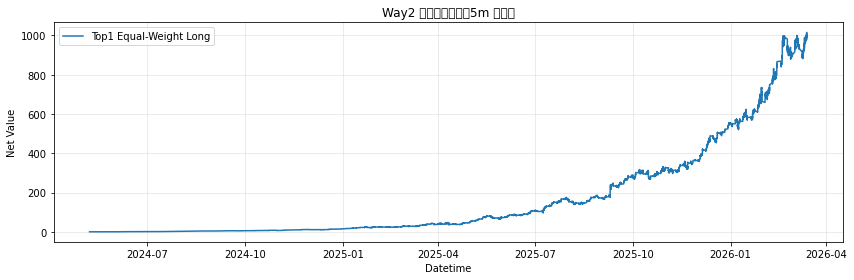

In [7]:
import matplotlib.pyplot as plt
import polars as pl

if "way2_backtest_df" not in globals():
    raise ValueError("请先运行训练格。")

TOP_K = 1

pred_df = way2_backtest_df.with_columns([
    pl.col("pred_ret_5m").rank("dense", descending=True).over("datetime").alias("pred_rank"),
])

port_df = (
    pred_df.filter(pl.col("pred_rank") <= TOP_K)
    .group_by("datetime")
    .agg([
        pl.col("target_fwd_5m").mean().alias("portfolio_ret_5m"),
        pl.len().alias("n_holdings"),
    ])
    .sort("datetime")
)

port_df = port_df.with_columns([
    (pl.col("portfolio_ret_5m") + 1.0).cum_prod().alias("equity_curve"),
])

stats = port_df.select([
    pl.col("portfolio_ret_5m").mean().alias("mean_ret_5m"),
    pl.col("portfolio_ret_5m").std().alias("std_ret_5m"),
    pl.col("portfolio_ret_5m").sum().alias("sum_ret_5m"),
    pl.col("equity_curve").last().alias("final_nav"),
    pl.col("n_holdings").mean().alias("avg_holdings"),
]).to_dicts()[0]

print("回测统计（方式2 · 验证区间 · 全批标的合并）")
for k, v in stats.items():
    print(f"{k}: {v}")

plot_pd = port_df.select(["datetime", "equity_curve"]).to_pandas()
plt.figure(figsize=(12, 4))
plt.plot(plot_pd["datetime"], plot_pd["equity_curve"], label=f"Top{TOP_K} Equal-Weight Long")
plt.title("Way2 验证区间净值（5m 调仓）")
plt.xlabel("Datetime")
plt.ylabel("Net Value")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()